# Model comparison

Notebook objectives:

- load the feature-engineered dataset;
- reuse the same time-based train/test split as the baseline model;
- train several regression models;
- compare model performance using MAE, RMSE, and R²;
- identify which model improves over the linear regression baseline.

In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import warnings

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
data_path ="../data/processed/electricity_weather_features.csv"
df = pd.read_csv(data_path)
df["date"] = pd.to_datetime(df["date"])

df.head()

,date,AWND,PRCP,TMAX,TMIN,daily_consumption,is_low_consumption_outlier,year,month,day_of_week,day_of_year,is_weekend,temperature_range,temperature_mean,heating_degree_days,cooling_degree_days
0,2006-12-16,2.5,0.0,10.6,5.0,1209.176,False,2006,12,5,350,True,5.6,7.80,10.20,0.0
1,2006-12-17,2.6,0.0,13.3,5.6,3390.460,False,2006,12,6,351,True,7.7,9.45,8.55,0.0
2,2006-12-18,2.4,0.0,15.0,6.7,2203.826,False,2006,12,0,352,False,8.3,10.85,7.15,0.0
3,2006-12-19,2.4,0.0,7.2,2.2,1666.194,False,2006,12,1,353,False,5.0,4.70,13.30,0.0
4,2006-12-20,2.4,0.0,7.2,1.1,2225.748,False,2006,12,2,354,False,6.1,4.15,13.85,0.0


## Feature and target selection

We use the same feature set and target variable as in the baseline model notebook.

In [3]:
target_column = "daily_consumption"

feature_columns = [
    "AWND",
    "PRCP",
    "TMAX",
    "TMIN",
    "month",
    "day_of_week",
    "day_of_year",
    "is_weekend",
    "temperature_range",
    "temperature_mean",
    "heating_degree_days",
    "cooling_degree_days"
]

X = df[feature_columns]
y = df[target_column]

X.head()

,AWND,PRCP,TMAX,TMIN,month,day_of_week,day_of_year,is_weekend,temperature_range,temperature_mean,heating_degree_days,cooling_degree_days
0,2.5,0.0,10.6,5.0,12,5,350,True,5.6,7.80,10.20,0.0
1,2.6,0.0,13.3,5.6,12,6,351,True,7.7,9.45,8.55,0.0
2,2.4,0.0,15.0,6.7,12,0,352,False,8.3,10.85,7.15,0.0
3,2.4,0.0,7.2,2.2,12,1,353,False,5.0,4.70,13.30,0.0
4,2.4,0.0,7.2,1.1,12,2,354,False,6.1,4.15,13.85,0.0


## Time-based train/test split

To keep the comparison fair, all models use the same time-based split.

In [4]:
split_date = "2010-01-01"

train_mask = df["date"] < split_date
test_mask = df["date"] >= split_date

X_train = X[train_mask]
X_test = X[test_mask]

y_train = y[train_mask]
y_test = y[test_mask]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((1110, 12), (323, 12), (1110,), (323,))

## Model training

We train several regression models using the same training data.

In [5]:
models = {
    "Linear Regression" : LinearRegression(),
    "Random Forest" : RandomForestRegressor(random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42)
}

In [6]:
results = []
trained_models = {}

for model_name, model in models.items():
    model.fit(X_train, y_train)

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning)
        y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results.append({
        "model": model_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2": r2
    })

    trained_models[model_name] = model

results_df = pd.DataFrame(results).sort_values("RMSE")
results_df


,model,MAE,RMSE,R2
2,Gradient Boosting,306.951213,421.699580,0.304022
0,Linear Regression,344.906377,442.850115,0.232457
1,Random Forest,326.857941,449.428440,0.209485


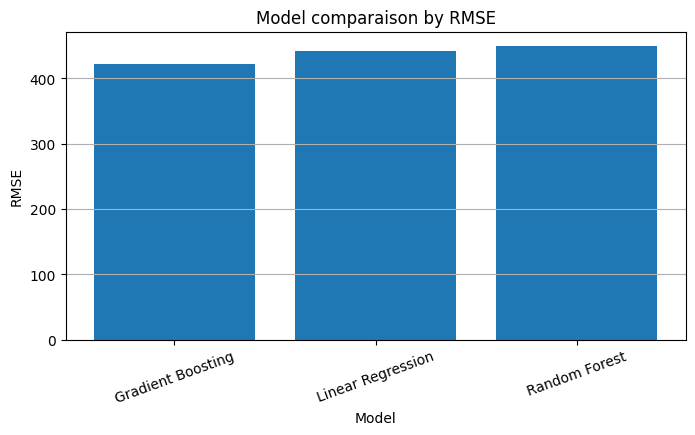

In [7]:
plt.figure(figsize=(8,4))

plt.bar(results_df["model"], results_df["RMSE"])

plt.title("Model comparaison by RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=20)
plt.grid(axis="y")

plt.show()

In [8]:
results_df.set_index("model")[["MAE", "RMSE", "R2"]]

,MAE,RMSE,R2
model,,,
Gradient Boosting,306.951213,421.699580,0.304022
Linear Regression,344.906377,442.850115,0.232457
Random Forest,326.857941,449.428440,0.209485


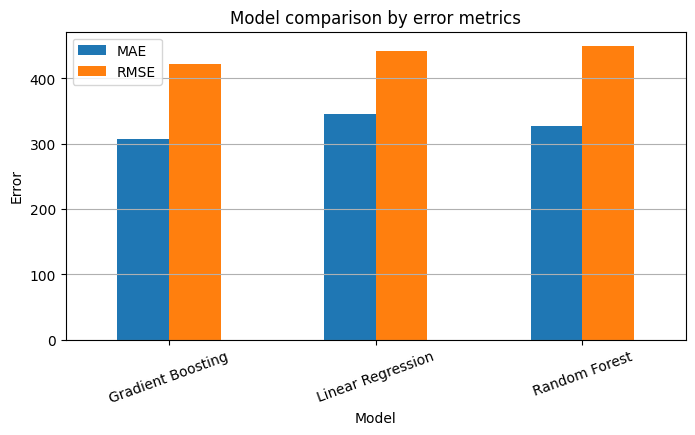

In [9]:
results_df.set_index("model")[["MAE", "RMSE"]].plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Model comparison by error metrics")
plt.xlabel("Model")
plt.ylabel("Error")
plt.xticks(rotation=20)
plt.grid(axis="y")

plt.show()

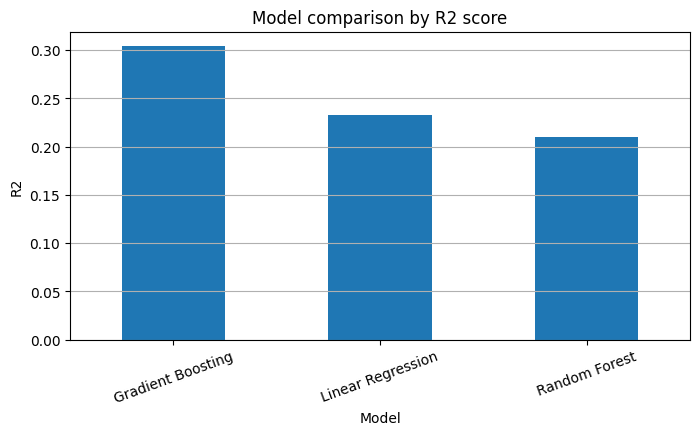

In [10]:
r2_scores = results_df.set_index("model")["R2"]

r2_scores.plot(
    kind="bar",
    figsize=(8, 4)
)

plt.title("Model comparison by R2 score")
plt.xlabel("Model")
plt.ylabel("R2")
plt.xticks(rotation=20)
plt.grid(axis="y")

plt.show()

In [11]:
best_model_name = results_df.iloc[0]["model"]
best_model = trained_models[best_model_name]

best_model_name

'Gradient Boosting'

In [12]:
best_y_pred = best_model.predict(X_test)

comparison_df = pd.DataFrame({
    "date": df.loc[test_mask, "date"],
    "actual_consumption": y_test,
    "predicted_consumption": best_y_pred
})

comparison_df.head()

,date,actual_consumption,predicted_consumption
1110,2010-01-01,1224.252,1865.360360
1111,2010-01-02,1308.836,2276.818520
1112,2010-01-03,2083.454,2351.137096
1113,2010-01-04,1604.132,1969.431716
1114,2010-01-05,2219.780,1903.223070


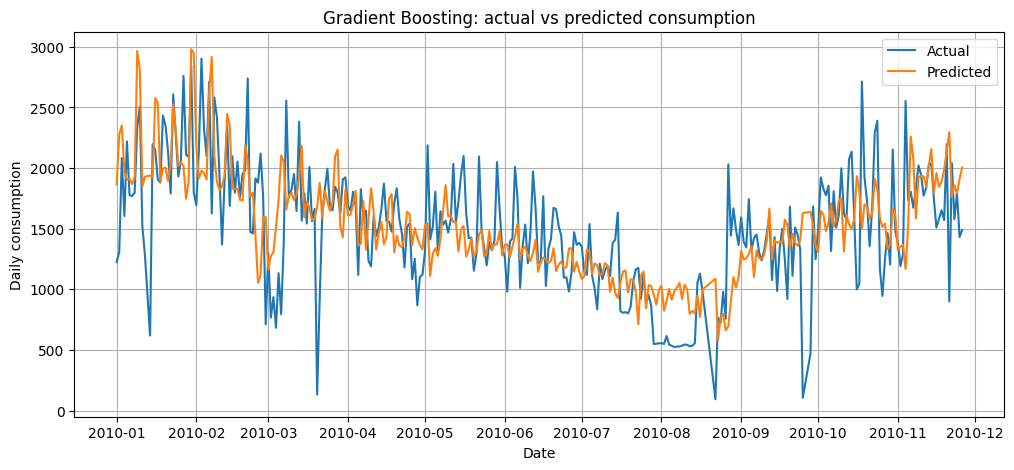

In [13]:
plt.figure(figsize=(12, 5))

plt.plot(comparison_df["date"], comparison_df["actual_consumption"], label="Actual")
plt.plot(comparison_df["date"], comparison_df["predicted_consumption"], label="Predicted")

plt.title("Gradient Boosting: actual vs predicted consumption")
plt.xlabel("Date")
plt.ylabel("Daily consumption")
plt.legend()
plt.grid(True)

plt.show()

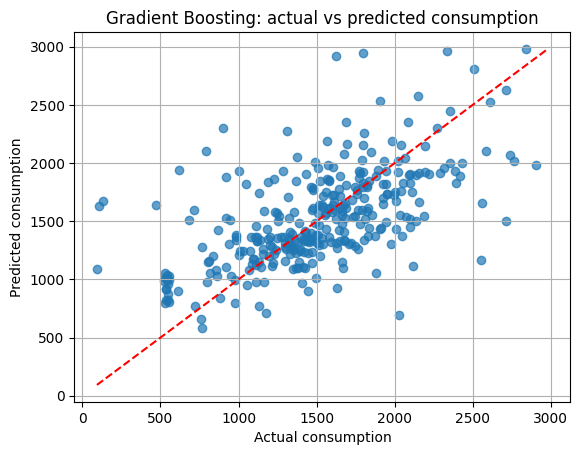

In [14]:
plt.scatter(
    comparison_df["actual_consumption"],
    comparison_df["predicted_consumption"],
    alpha=0.7
)

min_value = min(
    comparison_df["actual_consumption"].min(),
    comparison_df["predicted_consumption"].min()
)

max_value= max(
    comparison_df["actual_consumption"].max(),
    comparison_df["predicted_consumption"].max()
)

plt.plot(
    [min_value,max_value],
    [min_value,max_value],
    color="red",
    linestyle="--"
)

plt.title("Gradient Boosting: actual vs predicted consumption")
plt.xlabel("Actual consumption")
plt.ylabel("Predicted consumption")
plt.grid(True)

plt.show()

In [15]:
comparison_df["error"]= (
    comparison_df["actual_consumption"]-comparison_df["predicted_consumption"]
)

comparison_df["absolute_error"]= comparison_df["error"].abs()

comparison_df.head()

,date,actual_consumption,predicted_consumption,error,absolute_error
1110,2010-01-01,1224.252,1865.360360,-641.108360,641.108360
1111,2010-01-02,1308.836,2276.818520,-967.982520,967.982520
1112,2010-01-03,2083.454,2351.137096,-267.683096,267.683096
1113,2010-01-04,1604.132,1969.431716,-365.299716,365.299716
1114,2010-01-05,2219.780,1903.223070,316.556930,316.556930


In [16]:
comparison_df.sort_values("absolute_error", ascending=False).head(10)

,date,actual_consumption,predicted_consumption,error,absolute_error
1187,2010-03-20,131.732,1675.776430,-1544.044430,1544.044430
1372,2010-09-25,106.006,1629.343972,-1523.337972,1523.337972
1427,2010-11-21,900.910,2297.352529,-1396.442529,1396.442529
1410,2010-11-04,2555.146,1167.749564,1387.396436,1387.396436
1343,2010-08-27,2030.650,694.667521,1335.982479,1335.982479
1122,2010-01-14,618.488,1939.805869,-1321.317869,1321.317869
1173,2010-03-06,794.712,2104.953482,-1310.241482,1310.241482
1146,2010-02-07,1625.708,2917.130435,-1291.422435,1291.422435
1393,2010-10-18,2713.884,1499.045419,1214.838581,1214.838581
1373,2010-09-28,470.426,1640.461986,-1170.035986,1170.035986


## Conclusion

Gradient Boosting achieved the best performance among the tested models, with the lowest RMSE and the highest R² score.

Compared with the linear regression baseline, tree-based models can capture more complex relationships between weather, calendar features, and electricity consumption. However, the improvement remains limited: the best model still misses several abrupt daily changes and extreme consumption values.

This suggests that the current weather and calendar variables explain part of the consumption pattern, but additional information would likely be needed for stronger predictions. Useful future features could include lagged consumption values, holidays, occupancy patterns, and electricity price information.